In [50]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(
    "/workspaces/Effector-Structure-Prediction/04_results_tsv/pdb_metadata_af3.tsv",
    sep="\t"
)

df.columns = df.columns.str.strip()
print(df.columns.tolist())

['PDB_ID', 'Chain', 'Annotation', 'Organism', 'Deposition_date', 'Structural family (inferred from La Naour Vernet et al. (2025))', 'How many protein identities in crystal structure', 'Method', 'Resolution', 'TM_score_crystal_esm', 'TM_score_pred_esm', 'RMSD_esm', 'Aligned_length_esm', 'Seq_ID_esm', 'Pred_length_esm', 'Experimental_length_esm', 'Coverage_esm', 'runtime_seconds_esm', 'TM_score_crystal_af2', 'TM_score_pred_af2', 'RMSD_af2', 'Aligned_length_af2', 'Seq_ID_af2', 'Pred_length_af2', 'Experimental_length_af2', 'Coverage_af2', 'TM_score_crystal_af3', 'TM_score_pred_af3', 'RMSD_af3', 'Aligned_length_af3', 'Seq_ID_af3', 'Pred_length_af3', 'Experimental_length_af3', 'Coverage_af3', 'runtime_seconds_af3']


In [65]:
df_new = pd.read_csv(
    "/workspaces/Effector-Structure-Prediction/04_results_tsv/pdb_metadata.tsv",
    sep="\t"
)

print(df_new.head().to_markdown(index=False))

| PDB_ID   | Chain   | Annotation                  | Organism                             | Deposition_date               | Structural family (inferred from La Naour Vernet et al. (2025))   |   How many protein identities in crystal structure | Method       |   Resolution |
|:---------|:--------|:----------------------------|:-------------------------------------|:------------------------------|:------------------------------------------------------------------|---------------------------------------------------:|:-------------|-------------:|
| 1FN8_1   | A       | TRYPSIN                     | Fusarium oxysporum (5507)            | 2000-08-21T00:00:00.000+00:00 | HYDROLASE/HYDROLASE SUBSTRATE (non secreted)                      |                                                  2 | 0            |         0.81 |
| 1KG1_1   | A       | Necrosis Inducing Protein 1 | Rhynchosporium secalis (38038)       | 2001-11-26T00:00:00.000+00:00 | /                                                  

In [64]:
df

,PDB_ID,Chain,Annotation,Organism,Deposition_date,Structural family (inferred from La Naour Vernet et al. (2025)),How many protein identities in crystal structure,Method,Resolution,TM_score_crystal_esm,...,Aligned_length_af3,Seq_ID_af3,Pred_length_af3,Experimental_length_af3,Coverage_af3,runtime_seconds_af3,Structural_family_simplified,Organism_simplified,Method_simplified,Deposition_year
0,1FN8_1,A,TRYPSIN,Fusarium oxysporum (5507),2000-08-21T00:00:00.000+00:00,HYDROLASE/HYDROLASE SUBSTRATE (non secreted),2.0,0,0.81,0.99131,...,224,1.000,224,224,1.000000,751,Other,Fusarium oxysporum,Other,2000
1,1KG1_1,A,Necrosis Inducing Protein 1,Rhynchosporium secalis (38038),2001-11-26T00:00:00.000+00:00,/,1.0,Solution NMR,0,0.30002,...,35,0.457,60,60,1.000000,737,Other,Other,Solution NMR,2001
2,1KPT_1,"A, B",KP4 TOXIN,Ustilago maydis (5270),1995-06-06T00:00:00.000+00:00,KP4-like,1.0,X-ray,1.75,0.96012,...,105,1.000,105,105,1.000000,719,KP4-like,Other,X-ray,1995
3,1ZLD_1,A,Ptr necrosis toxin,Pyrenophora tritici-repentis (45151),2005-05-06T00:00:00.000+00:00,ToxA-like,1.0,X-ray,1.65,0.53198,...,101,0.950,118,102,0.864407,733,ToxA-like,Pyrenophora tritici-repentis,X-ray,2005
4,1ZLE_1,"A, B, C",Ptr necrosis toxin,Pyrenophora tritici-repentis (45151),2005-05-06T00:00:00.000+00:00,ToxA-like,1.0,X-ray,1.9,0.53400,...,100,0.900,118,102,0.864407,774,ToxA-like,Pyrenophora tritici-repentis,X-ray,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,8OXL_1,"A, B",AVRA7,Blumeria hordei DH14 (546991),2023-05-02T00:00:00.000+00:00,RALPH,1.0,X-ray,1.56,0.36122,...,92,1.000,92,92,1.000000,643,RALPH,Blumeria hordei,X-ray,2023
83,8R7A_2,B,Pwl2 protein,Pyricularia oryzae (318829),2023-11-24T00:00:00.000+00:00,MAX,2.0,X-ray,1.8,0.52706,...,94,0.936,145,112,0.772414,673,MAX,Magnaporthe oryzae,X-ray,2023
84,8V1J_1,"A, B",AvrSr27,Puccinia graminis f. sp. tritici (56615),2023-11-20T00:00:00.000+00:00,/,1.0,X-ray,2.42,0.35709,...,79,0.785,120,115,0.958333,778,Other,Puccinia graminis,X-ray,2023
85,9FEI_1,A,Defoliating protein: protein D,Fusarium oxysporum (5507),2024-05-20T00:00:00.000+00:00,D Effector,1.0,X-ray,1.47,0.28069,...,133,0.639,239,185,0.774059,668,Other,Fusarium oxysporum,X-ray,2024


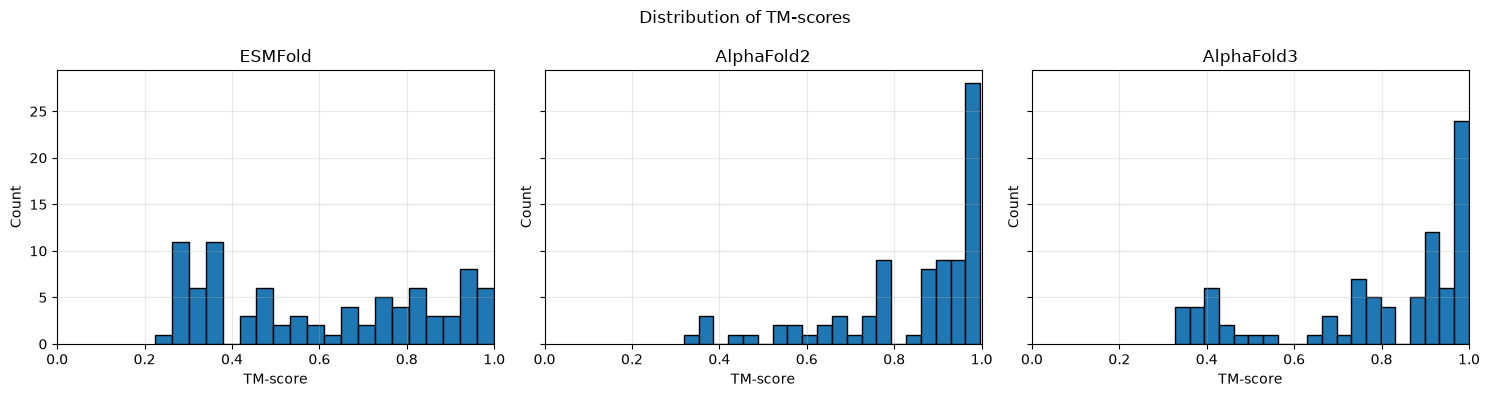

In [55]:
tm_columns = [
    "TM_score_crystal_esm",
    "TM_score_crystal_af2",
    "TM_score_crystal_af3",
]

titles = [
    "ESMFold",
    "AlphaFold2",
    "AlphaFold3",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, col, title in zip(axes, tm_columns, titles):

    ax.hist(
        df[col].dropna(),
        bins=20,
        edgecolor="black"
    )

    ax.set_title(title)
    ax.set_xlabel("TM-score")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

fig.suptitle("Distribution of TM-scores")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3716/3168087499.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_3716/3168087499.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_3716/3168087499.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


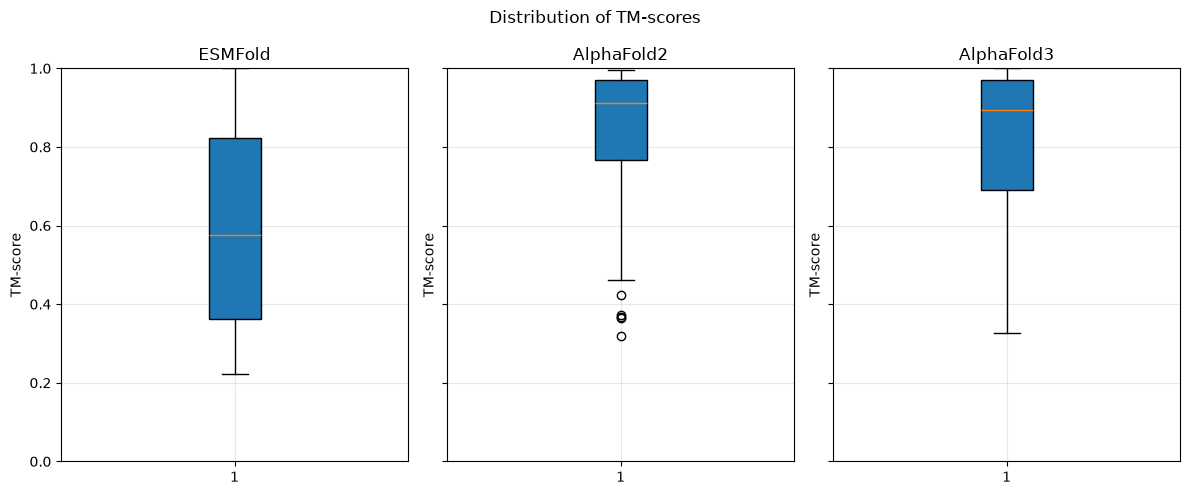

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

for ax, col, title in zip(axes, tm_columns, titles):

    ax.boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True
    )

    ax.set_title(title)
    ax.set_ylabel("TM-score")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.suptitle("Distribution of TM-scores")
plt.tight_layout()
plt.show()

In [57]:
# Simplify the families
families = {
    "AvrSr35-like",
    "FOLD",
    "KP4-like",
    "LARS",
    "MAX",
    "RALPH",
    "ToxA-like",
}

def simplify_family(family):
    family = str(family).strip()
    return family if family in families else "Other"

df["Structural_family_simplified"] = df[
    "Structural family (inferred from La Naour Vernet et al. (2025))"
].apply(simplify_family)

print(df["Structural_family_simplified"].value_counts())

Structural_family_simplified
Other           29
MAX             26
ToxA-like        9
RALPH            7
FOLD             6
LARS             4
AvrSr35-like     4
KP4-like         2
Name: count, dtype: int64


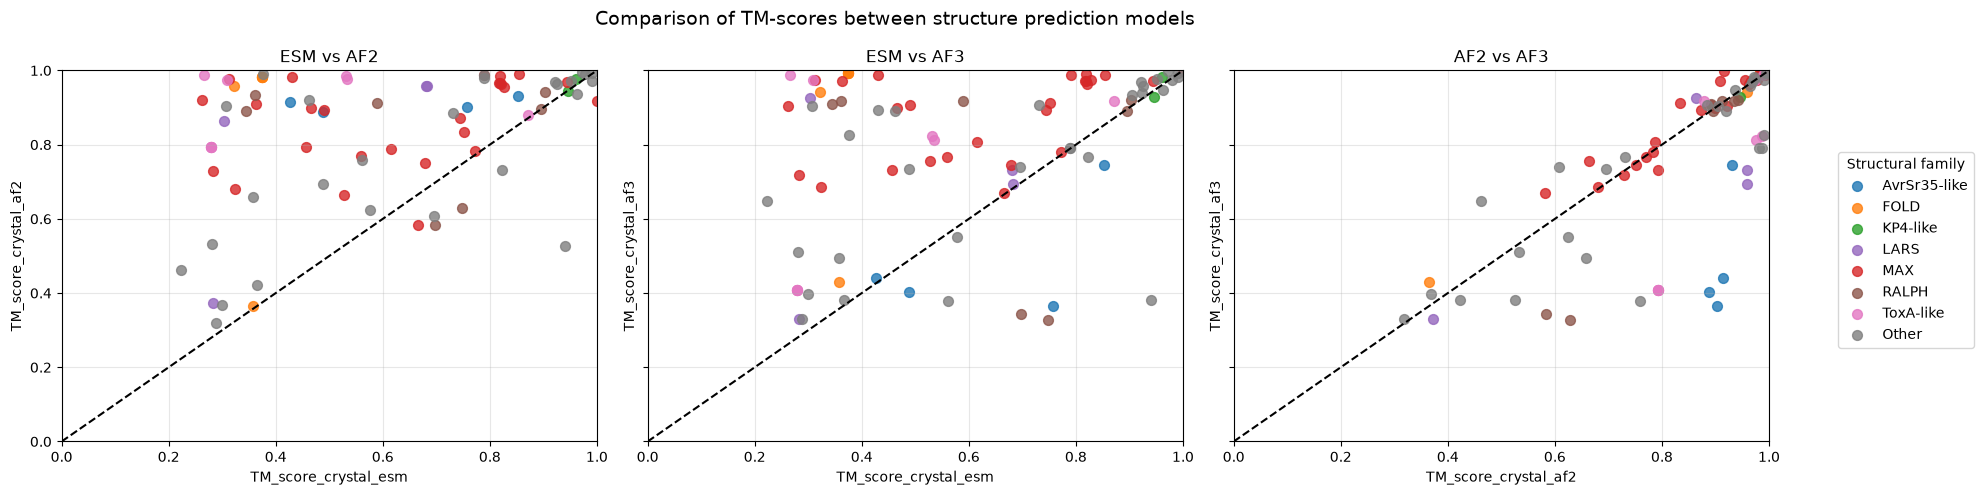

In [58]:
# Define the order of structural families
family_order = [
    'AvrSr35-like',
    'FOLD',
    'KP4-like',
    'LARS',
    'MAX',
    'RALPH',
    'ToxA-like',
    'Other'
]

# Colour mapping
family_colors = {
    'AvrSr35-like': 'tab:blue',
    'FOLD': 'tab:orange',
    'KP4-like': 'tab:green',
    'LARS': 'tab:purple',
    'MAX': 'tab:red',
    'RALPH': 'tab:brown',
    'ToxA-like': 'tab:pink',
    'Other': 'tab:gray'
}

comparisons = [
    ("TM_score_crystal_esm", "TM_score_crystal_af2", "ESM vs AF2"),
    ("TM_score_crystal_esm", "TM_score_crystal_af3", "ESM vs AF3"),
    ("TM_score_crystal_af2", "TM_score_crystal_af3", "AF2 vs AF3"),
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)


for ax, (xcol, ycol, title) in zip(axes, comparisons):

    for family in family_order:

        subset = df[
            df["Structural_family_simplified"] == family
        ]

        ax.scatter(
            subset[xcol],
            subset[ycol],
            label=family,
            color=family_colors[family],
            s=50,
            alpha=0.8
        )

    # perfect agreement line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_title(title)

    ax.grid(alpha=0.3)


# one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Structural family",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Comparison of TM-scores between structure prediction models",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [59]:
organism_map = {
    "blumeria hordei": "Blumeria hordei",
    "fusarium oxysporum": "Fusarium oxysporum",
    "magnaporthe oryzae": "Magnaporthe oryzae",
    "pyricularia oryzae": "Magnaporthe oryzae",
    "puccinia graminis": "Puccinia graminis",
    "pyrenophora tritici-repentis": "Pyrenophora tritici-repentis",
}

def simplify_organism(org):
    org = str(org).lower()

    for key, value in organism_map.items():
        if key in org:
            return value

    return "Other"


df["Organism_simplified"] = df["Organism"].apply(simplify_organism)

print(df["Organism_simplified"].value_counts())

Organism_simplified
Other                           33
Magnaporthe oryzae              26
Fusarium oxysporum              14
Puccinia graminis                6
Pyrenophora tritici-repentis     4
Blumeria hordei                  4
Name: count, dtype: int64


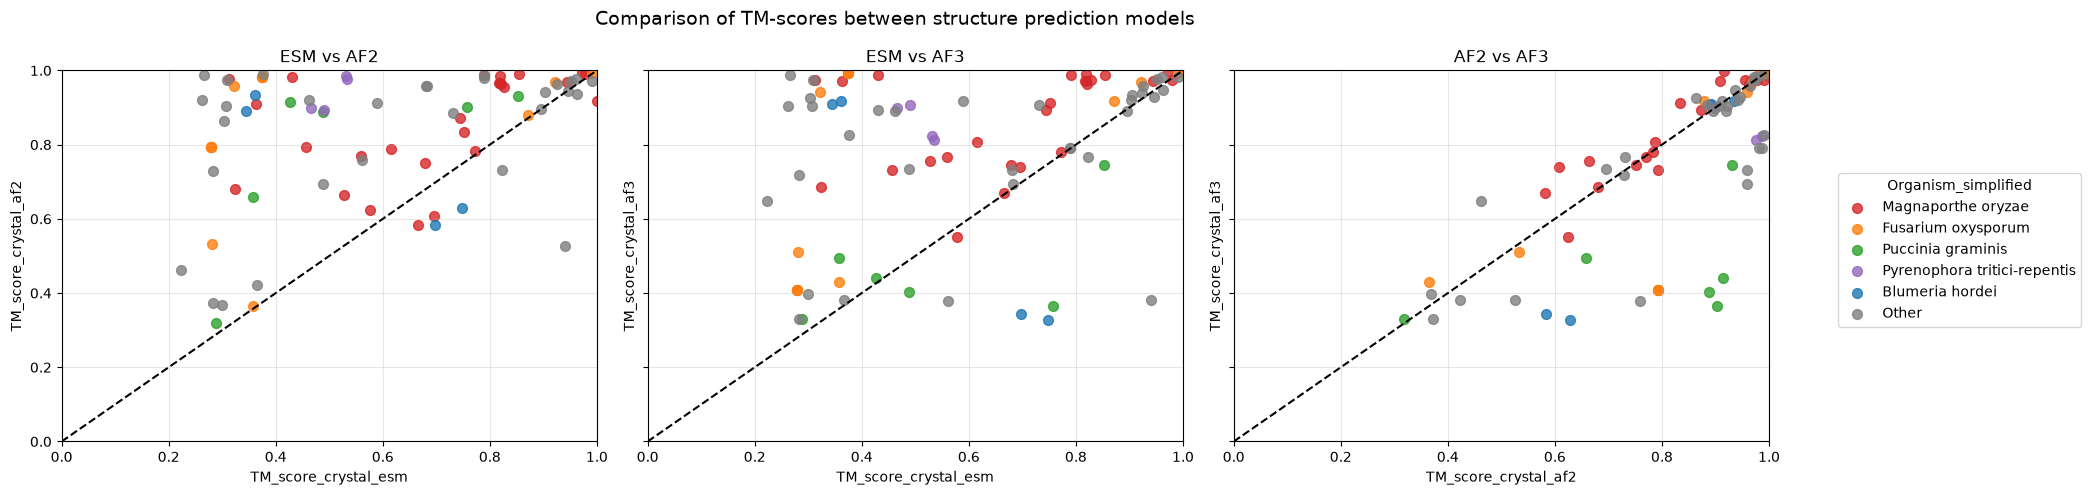

In [60]:
# Define the order of structural families
family_order = [
    'Magnaporthe oryzae',
    'Fusarium oxysporum',
    'Puccinia graminis',
    'Pyrenophora tritici-repentis',
    'Blumeria hordei',
    'Other'
]

# Colour mapping
family_colors = {
    'Other': 'tab:gray',
    'Magnaporthe oryzae': 'tab:red',
    'Fusarium oxysporum':'tab:orange',
    'Puccinia graminis':'tab:green',
    'Pyrenophora tritici-repentis':'tab:purple',
    'Blumeria hordei':'tab:blue'
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)


for ax, (xcol, ycol, title) in zip(axes, comparisons):

    for family in family_order:

        subset = df[
            df["Organism_simplified"] == family
        ]

        ax.scatter(
            subset[xcol],
            subset[ycol],
            label=family,
            color=family_colors[family],
            s=50,
            alpha=0.8
        )

    # perfect agreement line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_title(title)

    ax.grid(alpha=0.3)


# one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Organism_simplified",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Comparison of TM-scores between structure prediction models",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [61]:
def simplify_method(method):

    method = str(method).lower()

    if "nmr" in method:
        return "Solution NMR"

    elif "x-ray" in method or "xray" in method:
        return "X-ray"

    elif "electron" in method or "em" in method:
        return "Electron microscopy"

    else:
        return "Other"

df["Method_simplified"] = df["Method"].apply(simplify_method)
print(df["Method_simplified"].value_counts())

Method_simplified
X-ray                  65
Solution NMR           16
Electron microscopy     4
Other                   2
Name: count, dtype: int64


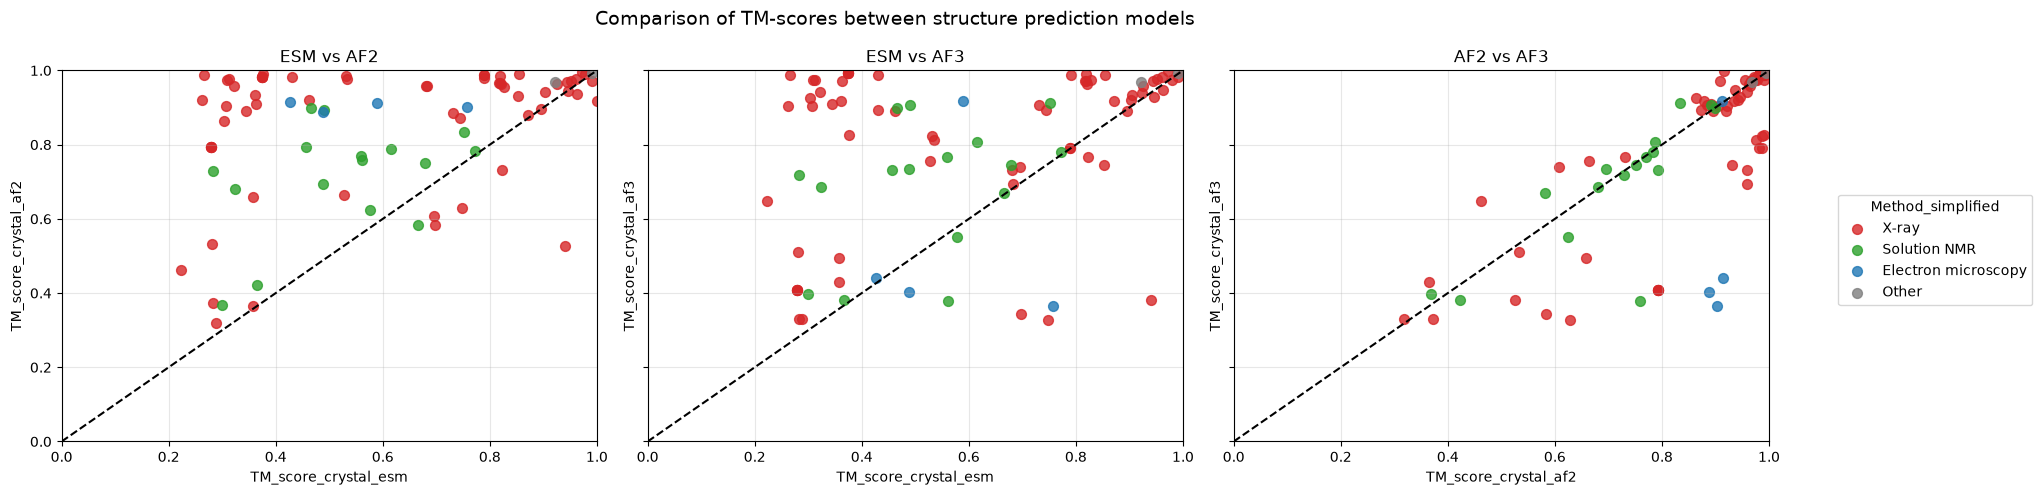

In [62]:
# Define the order of structural families
family_order = [
    'X-ray',
    'Solution NMR',
    'Electron microscopy',
    'Other',
]

# Colour mapping
family_colors = {
    'X-ray': 'tab:red',
    'Solution NMR':'tab:green',
    'Electron microscopy':'tab:blue',
    'Other' :'tab:gray',
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)


for ax, (xcol, ycol, title) in zip(axes, comparisons):

    for family in family_order:

        subset = df[
            df["Method_simplified"] == family
        ]

        ax.scatter(
            subset[xcol],
            subset[ycol],
            label=family,
            color=family_colors[family],
            s=50,
            alpha=0.8
        )

    # perfect agreement line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_title(title)

    ax.grid(alpha=0.3)


# one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Method_simplified",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Comparison of TM-scores between structure prediction models",
    fontsize=14
)

plt.tight_layout()
plt.show()

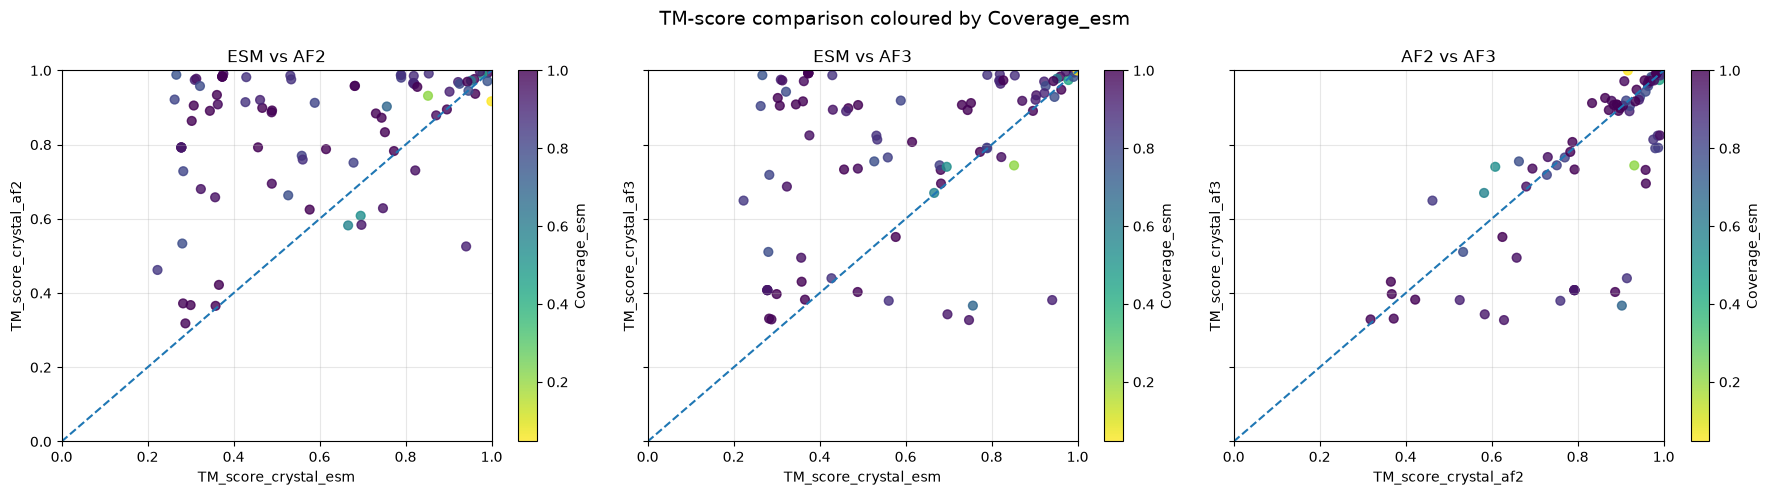

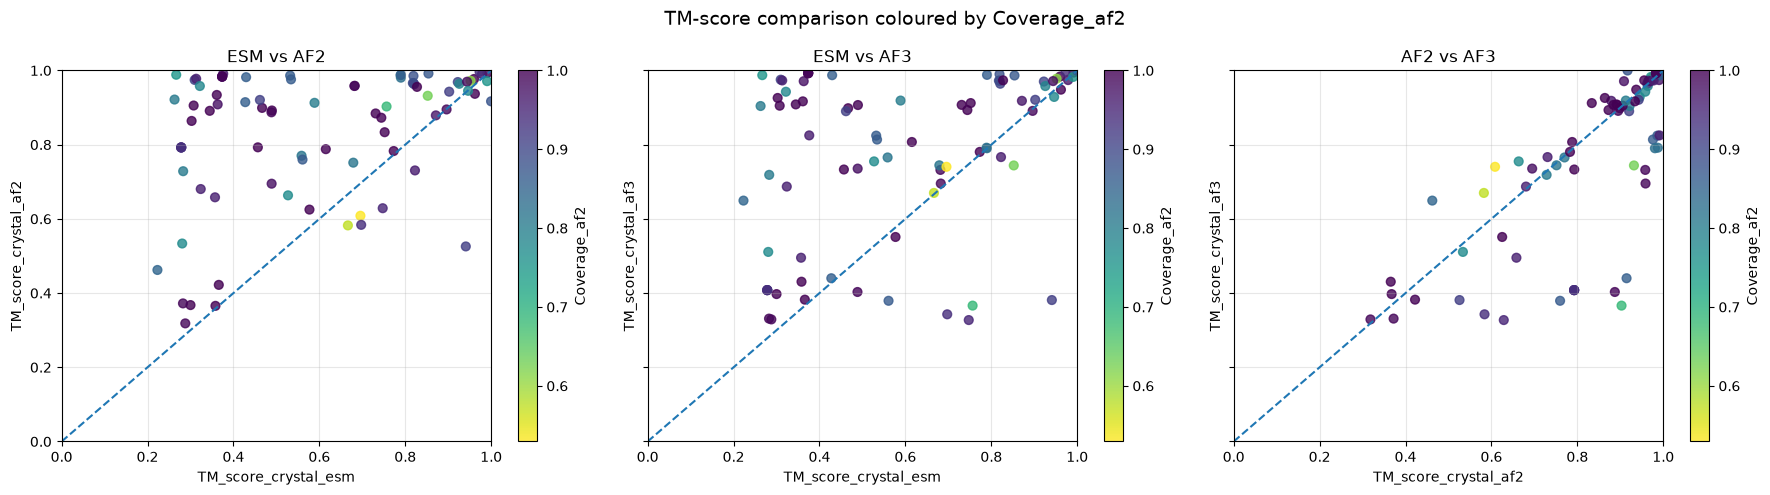

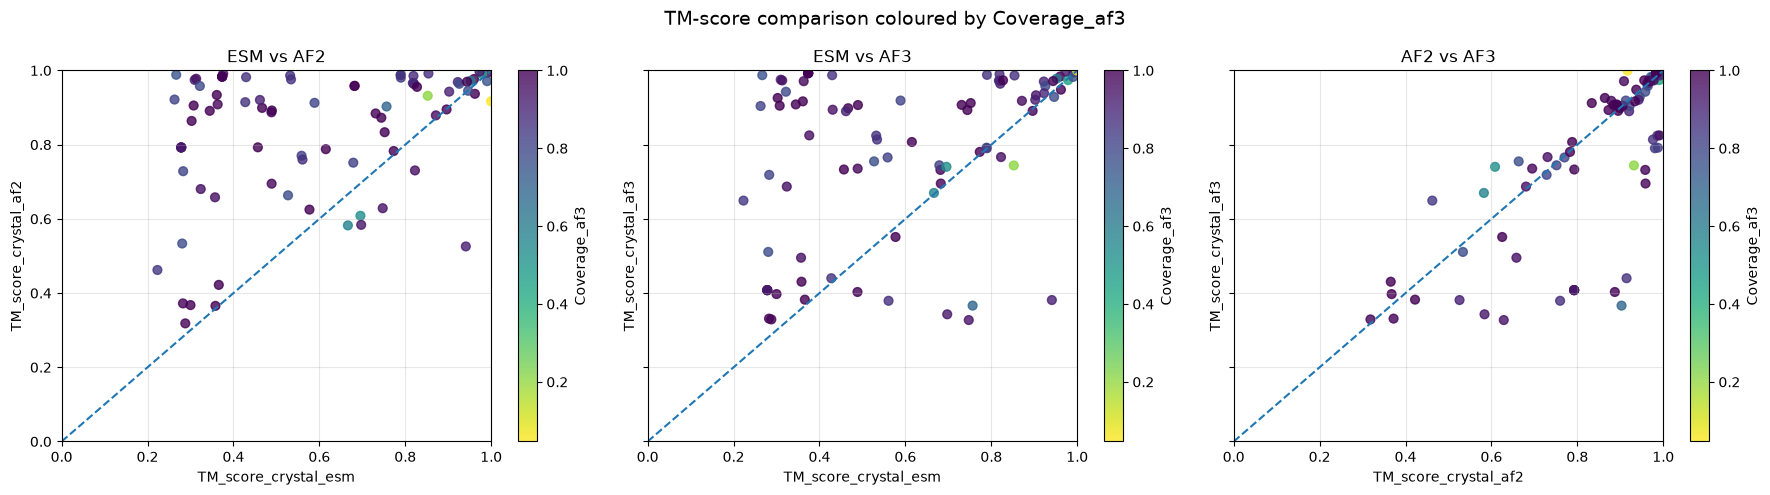

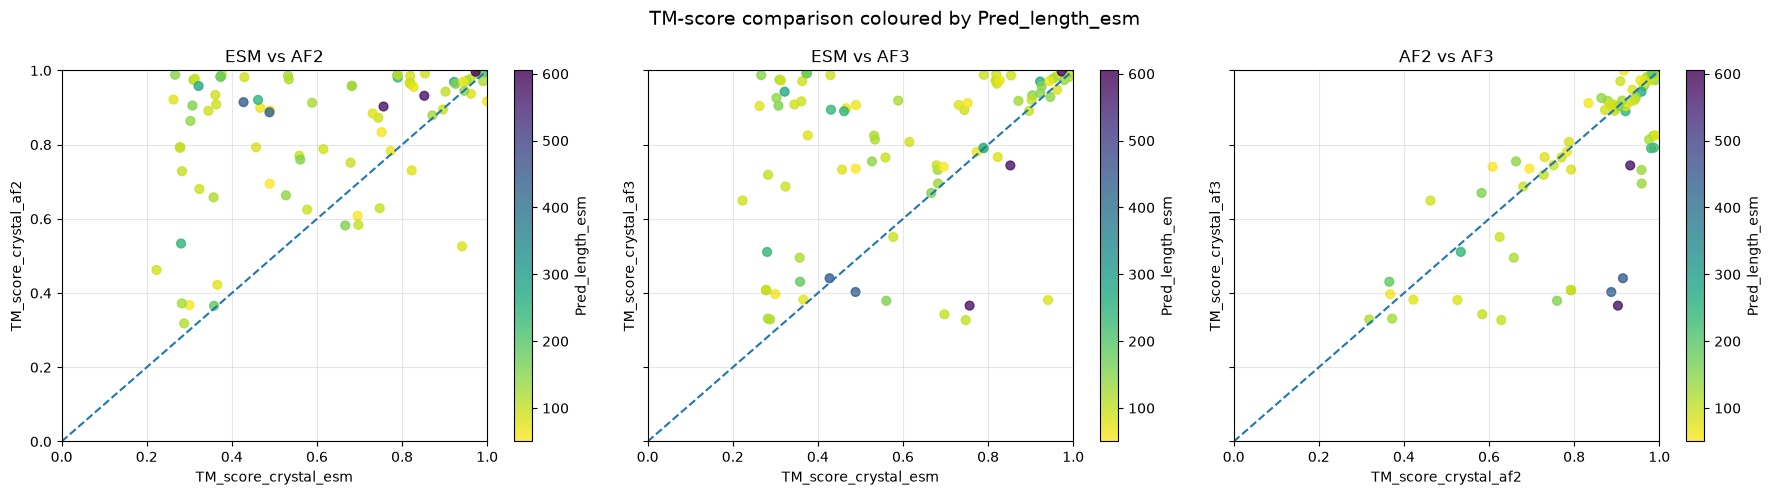

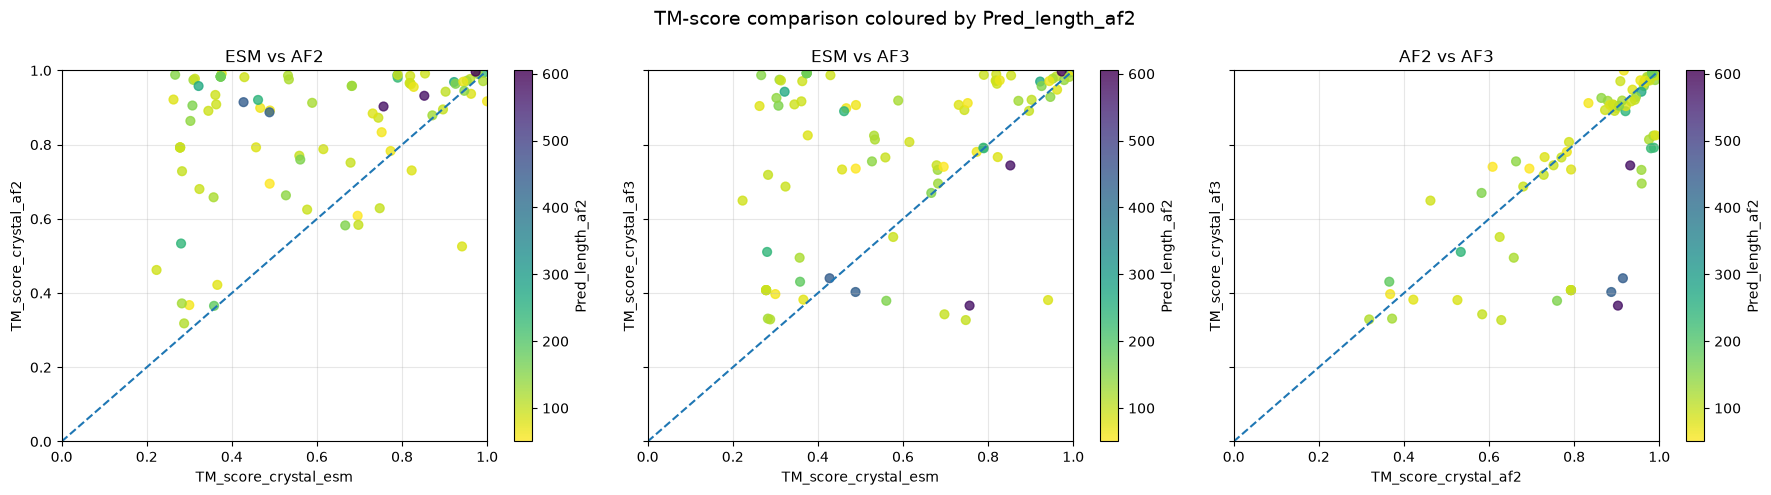

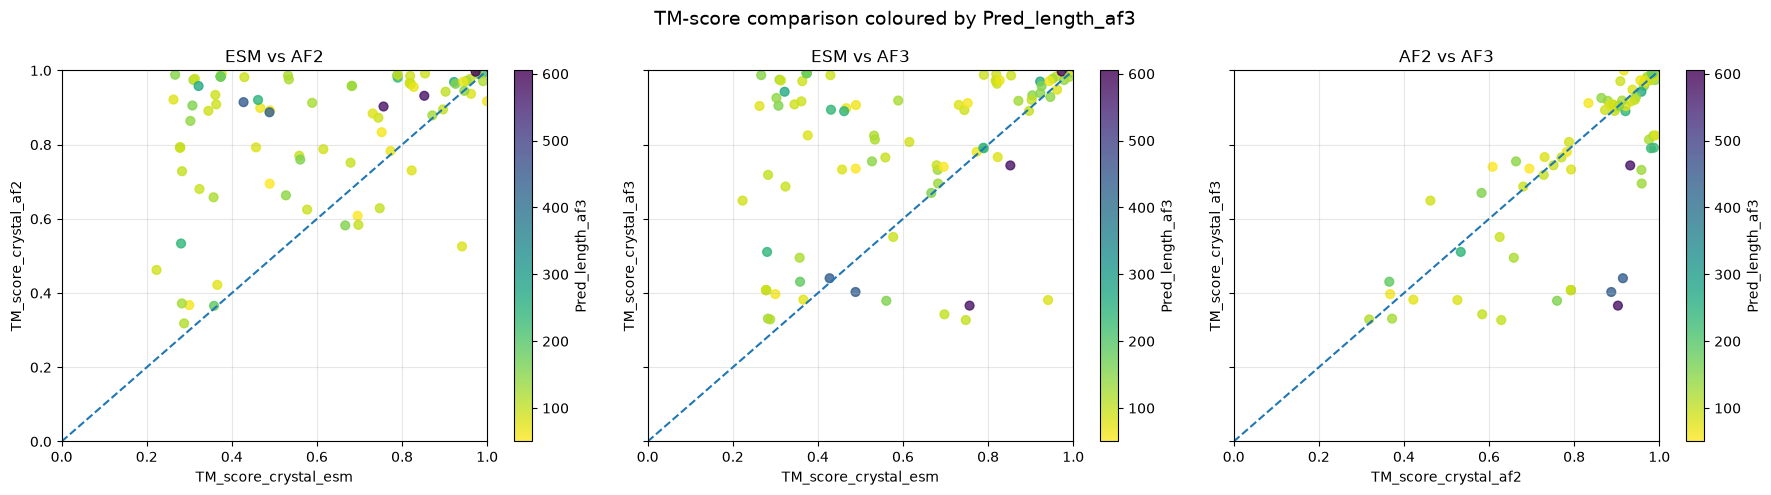

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0     0.81
1        0
2     1.75
3     1.65
4      1.9
      ... 
82    1.56
83     1.8
84    2.42
85    1.47
86     3.8
Name: Resolution, Length: 87, dtype: str

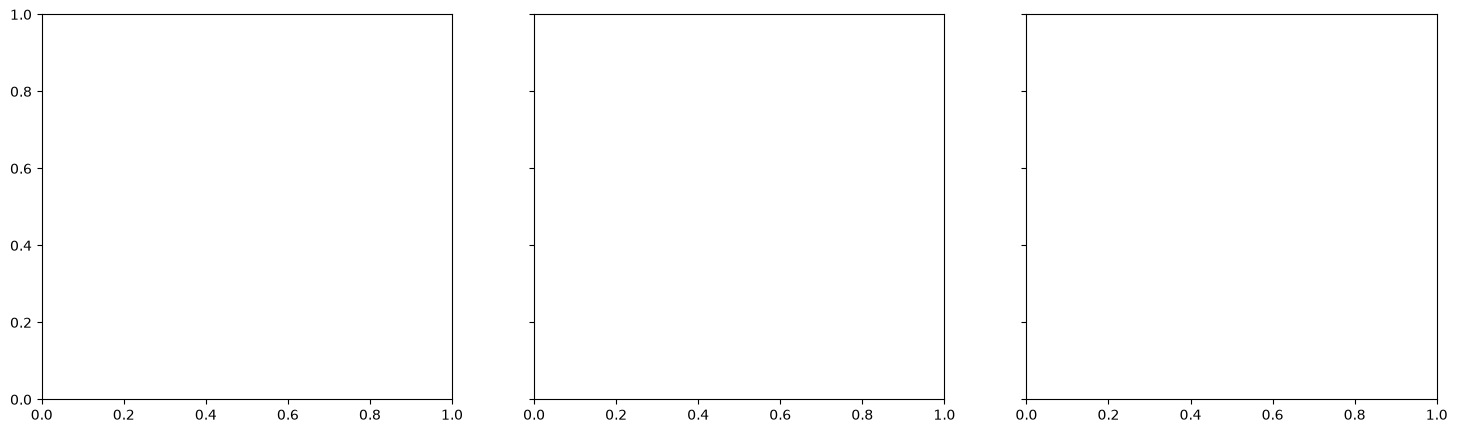

In [63]:
df["Deposition_year"] = pd.to_datetime(
    df["Deposition_date"]
).dt.year

continuous_metadata = [
    "Coverage_esm",
    "Coverage_af2",
    "Coverage_af3",
    "Pred_length_esm",
    "Pred_length_af2",
    "Pred_length_af3",
    "Resolution",
    "Deposition_year",
    "How many protein identities in crystal structure",
    "runtime_seconds_esm",
    "runtime_seconds_af3",
    "Aligned_length_esm",
    "Seq_ID_esm",
    'Experimental_length_esm'
]

# ['TM_score_pred_esm', 'RMSD_esm', 'Aligned_length_esm', 'Seq_ID_esm', 'Pred_length_esm', 'Experimental_length_esm', 'Coverage_esm', 'runtime_seconds_esm', 'TM_score_crystal_af2', 'TM_score_pred_af2', 'RMSD_af2', 'Aligned_length_af2', 'Seq_ID_af2', 'Pred_length_af2', 'Experimental_length_af2', 'Coverage_af2', 'TM_score_crystal_af3', 'TM_score_pred_af3', 'RMSD_af3', 'Aligned_length_af3', 'Seq_ID_af3', 'Pred_length_af3', 'Experimental_length_af3', 'Coverage_af3', 'runtime_seconds_af3', 'Structural family (inferred from La Naour Vernet et al. (2025))', 'How many protein identities in crystal structure', 'Method', 'Resolution']

for colour_column in continuous_metadata:

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5),
        sharex=True,
        sharey=True
    )

    for ax, (xcol, ycol, title) in zip(axes, comparisons):

        scatter = ax.scatter(
            df[xcol],
            df[ycol],
            c=df[colour_column],
            cmap="viridis_r",
            s=40,
            alpha=0.8
        )

        cbar = plt.colorbar(
            scatter,
            ax=ax
        )

        cbar.set_label(colour_column)

        # diagonal = equal performance
        ax.plot(
            [0, 1],
            [0, 1],
            "--"
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)

        ax.set_title(title)

        ax.grid(alpha=0.3)

    fig.suptitle(
        f"TM-score comparison coloured by {colour_column}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()
    plt.close()